|N(1)|=2 |N(2)|=2 |N(3)|=2 |N(4)|=2 |N(5)|=1
Core points: 1 2 3 4
Cluster Assignments: 1 1 2 2 0
Noise Ratio = 0.20


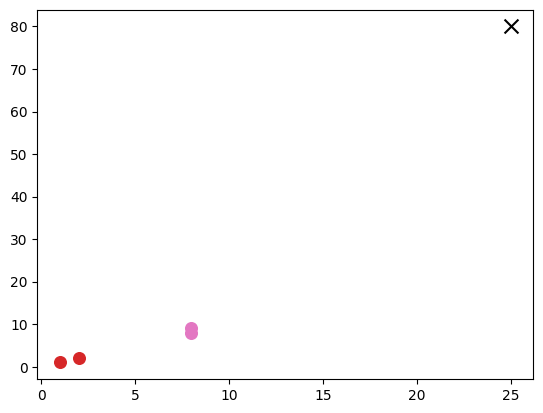

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def dbscan(X, eps, min_pts):
    n = X.shape[0]
    labels = np.zeros(n, dtype=int)
    visited = np.zeros(n, dtype=bool)
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=2))
    neighborhoods = [np.where(D[i] <= eps)[0] for i in range(n)]
    core_points = [i for i in range(n) if len(neighborhoods[i]) >= min_pts]
    cluster_id = 0
    for i in core_points:
        if not visited[i]:
            cluster_id += 1
            visited[i] = True
            seeds = list(neighborhoods[i])
            j = 0
            while j < len(seeds):
                p = seeds[j]
                if not visited[p]:
                    visited[p] = True
                    neighbors = list(np.where(D[p] <= eps)[0])
                    if len(neighbors) >= min_pts:
                        for n_idx in neighbors:
                            if n_idx not in seeds:
                                seeds.append(n_idx)
                if labels[p] == 0:
                    labels[p] = cluster_id
                j += 1
    return labels, core_points, neighborhoods

data = np.array([
    [1.0, 1.0],
    [2.0, 2.0],
    [8.0, 8.0],
    [8.0, 9.0],
    [25.0, 80.0]
])
eps = 3
min_pts = 2

labels, core_points, neighborhoods = dbscan(data, eps, min_pts)
neigh_counts = [len(nlist) for nlist in neighborhoods]
print(' '.join([f"|N({i+1})|={cnt}" for i, cnt in enumerate(neigh_counts)]))
print("Core points:", ' '.join(str(i+1) for i in core_points))
print("Cluster Assignments:", ' '.join(str(c) for c in labels))
noise_ratio = np.sum(labels == 0) / len(labels)
print(f"Noise Ratio = {noise_ratio:.2f}")

plt.figure()
unique_labels = np.unique(labels)
colors = plt.cm.tab10(unique_labels / (max(unique_labels)+1))
for lbl, col in zip(unique_labels, colors):
    mask = labels == lbl
    if lbl == 0:
        plt.scatter(data[mask,0], data[mask,1], c='k', marker='x', s=100)
    else:
        plt.scatter(data[mask,0], data[mask,1], c=[col], s=70)
plt.show()
